# Corpus Health Check
Runs against `data/corpus/BoE.csv`, `ECB.csv`, `Fed.csv`. Run all cells top-to-bottom; summary flag table is at the bottom.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path("..")  # repo root relative to notebooks/

boe = pd.read_csv(ROOT / "data/corpus/BoE.csv"); boe["bank"] = "BoE"
ecb = pd.read_csv(ROOT / "data/corpus/ECB.csv"); ecb["bank"] = "ECB"
fed = pd.read_csv(ROOT / "data/corpus/Fed.csv"); fed["bank"] = "Fed"

df = pd.concat([boe, ecb, fed], ignore_index=True)

# BoE dates are YYYYMM (6-digit), ECB/Fed are YYYYMMDD (8-digit)
def parse_date(val):
    s = str(val).strip()
    if len(s) == 6:
        return pd.to_datetime(s, format="%Y%m", errors="coerce")
    return pd.to_datetime(s, format="%Y%m%d", errors="coerce")

df["date"] = df["date"].apply(parse_date)
df["year"] = df["date"].dt.year
df["word_count"] = df["text"].str.split().str.len()

print(f"Loaded {len(df):,} turns across {df['doc_id'].nunique()} documents")

Loaded 3,972 turns across 206 documents


## 1. Basic Counts

In [2]:
summary = df.groupby("bank").agg(
    n_turns=("text", "count"),
    n_documents=("doc_id", "nunique"),
    n_speakers=("speaker", "nunique"),
    date_min=("date", "min"),
    date_max=("date", "max"),
).reset_index()
summary["date_range"] = (
    summary["date_min"].dt.strftime("%Y-%m")
    + " -> "
    + summary["date_max"].dt.strftime("%Y-%m")
)
display(summary[["bank", "n_turns", "n_documents", "n_speakers", "date_range"]])

,bank,n_turns,n_documents,n_speakers,date_range
0,BoE,895,44,3,2015-02 -> 2026-02
1,ECB,1163,89,2,2015-01 -> 2025-12
2,Fed,1914,73,2,2015-03 -> 2025-12


## 2. Timeline Coverage

In [3]:
flags_timeline = []
for bank, group in df.groupby("bank"):
    dates = sorted(group["date"].dropna().unique())
    for i in range(1, len(dates)):
        gap_days = (dates[i] - dates[i - 1]).days
        if gap_days > 183:
            flags_timeline.append({
                "bank": bank,
                "from": pd.Timestamp(dates[i - 1]).strftime("%Y-%m-%d"),
                "to": pd.Timestamp(dates[i]).strftime("%Y-%m-%d"),
                "gap_days": gap_days,
            })

if flags_timeline:
    print("WARNING: Gaps > 6 months between consecutive meetings:")
    display(pd.DataFrame(flags_timeline))
else:
    print("OK: No gaps > 6 months")

,bank,from,to,gap_days
0,BoE,2017-05-01,2017-11-01,184


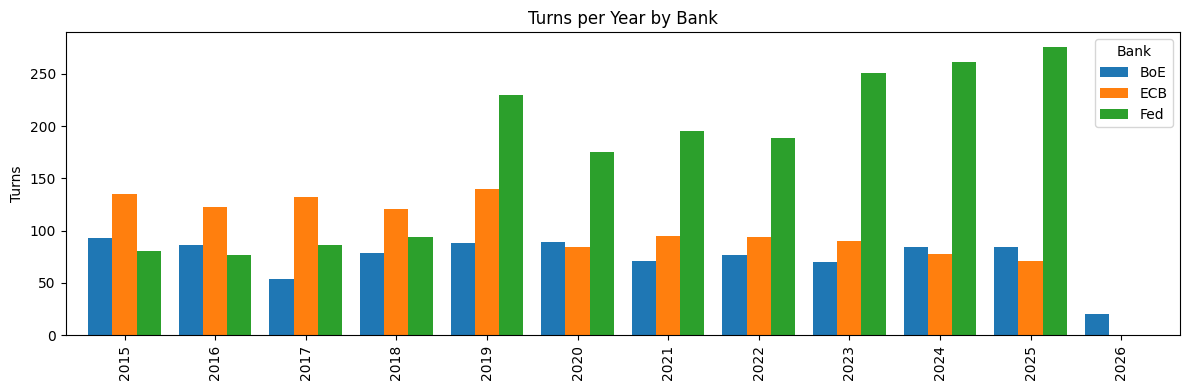

In [4]:
pivot = df.groupby(["year", "bank"]).size().unstack(fill_value=0)
pivot.plot(kind="bar", figsize=(12, 4), title="Turns per Year by Bank", width=0.8)
plt.ylabel("Turns")
plt.xlabel("")
plt.legend(title="Bank")
plt.tight_layout()
plt.show()

## 3. Turns per Document

In [5]:
turns_per_doc = df.groupby(["bank", "doc_id"]).size().reset_index(name="n_turns")

stats_tpd = turns_per_doc.groupby("bank")["n_turns"].agg(["min", "mean", "median", "max"]).round(1)
print("Turns per document:")
display(stats_tpd)

low_turn_docs = turns_per_doc[turns_per_doc["n_turns"] < 3]
if len(low_turn_docs):
    print(f"\nWARNING: {len(low_turn_docs)} doc(s) with < 3 turns (possible parsing failure):")
    display(low_turn_docs)
else:
    print("\nOK: All documents have >= 3 turns")

Turns per document:


,min,mean,median,max
bank,,,,
BoE,11,20.3,20.0,30
ECB,6,13.1,12.0,23
Fed,10,26.2,27.0,38



OK: All documents have >= 3 turns


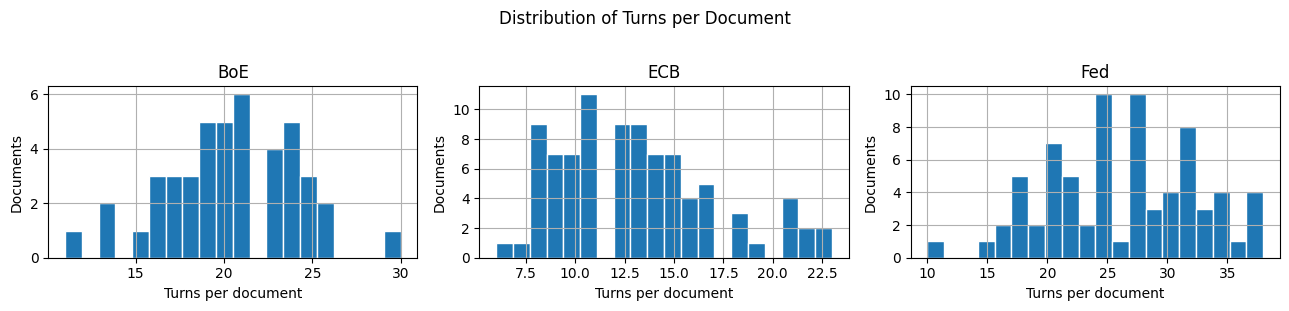

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=False)
for ax, (bank, grp) in zip(axes, turns_per_doc.groupby("bank")):
    grp["n_turns"].hist(bins=20, ax=ax, edgecolor="white")
    ax.set_title(bank)
    ax.set_xlabel("Turns per document")
    ax.set_ylabel("Documents")
fig.suptitle("Distribution of Turns per Document", y=1.02)
plt.tight_layout()
plt.show()

## 4. Text Length Distribution

In [7]:
stats_len = df.groupby("bank")["word_count"].agg(
    mean="mean",
    median="median",
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95),
    max="max",
).round(1)
print("Word count per turn:")
display(stats_len)

short_turns = df[df["word_count"] < 10][["bank", "doc_id", "turn_idx", "word_count", "text"]]
if len(short_turns):
    print(f"\nWARNING: {len(short_turns)} turn(s) with < 10 words:")
    display(short_turns)
else:
    print("\nOK: All turns have >= 10 words")

Word count per turn:


,mean,median,p5,p95,max
bank,,,,,
BoE,236.4,222.0,6.7,508.3,2182
ECB,269.7,237.0,14.0,633.0,1517
Fed,193.8,176.0,11.0,436.0,912


,bank,doc_id,turn_idx,word_count,text
12,BoE,BoE_201502_transcript,25,1,Yes.
38,BoE,BoE_201505_transcript,29,9,That's the central forecast; that is our centr...
39,BoE,BoE_201505_transcript,31,7,"Oh no, but it's in the Fan."
42,BoE,BoE_201505_transcript,37,3,A few times.
53,BoE,BoE_201508_transcript,13,7,"And that was your one question, Ed."
...,...,...,...,...,...
3934,Fed,FOMCpresconf20251029,67,4,That we're thinking of?
3951,Fed,FOMCpresconf20251210,31,7,"No, just one, just one more. [Laughter]"
3954,Fed,FOMCpresconf20251210,38,1,No.
3960,Fed,FOMCpresconf20251210,54,4,On the policy what?


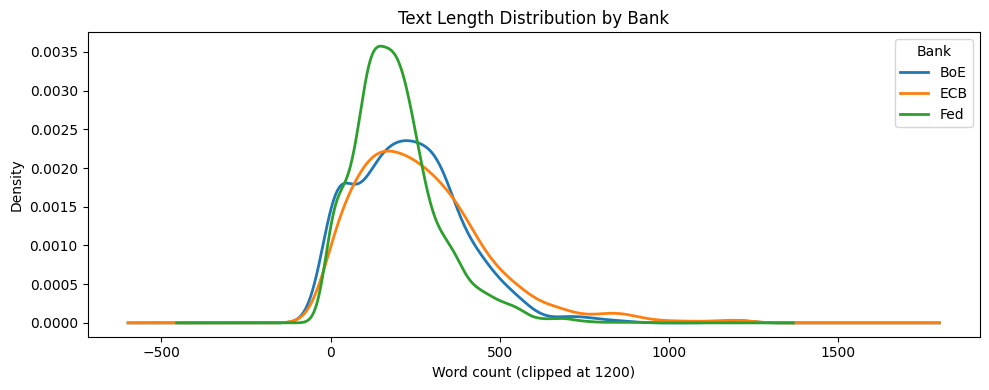

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for bank, grp in df.groupby("bank"):
    grp["word_count"].clip(upper=1200).plot.kde(ax=ax, label=bank, linewidth=2)
ax.set_xlabel("Word count (clipped at 1200)")
ax.set_ylabel("Density")
ax.set_title("Text Length Distribution by Bank")
ax.legend(title="Bank")
plt.tight_layout()
plt.show()

In [9]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

df["deberta_tokens"] = df["text"].astype(str).apply(
    lambda x: len(tok(x, truncation=False)["input_ids"])
)

token_stats = df.groupby("bank")["deberta_tokens"].agg(
    mean="mean",
    median="median",
    p5=lambda x: x.quantile(0.05),
    p95=lambda x: x.quantile(0.95),
    p99=lambda x: x.quantile(0.99),
    max="max",
).round(1)

display(token_stats)

trunc = (
    df.assign(truncated=df["deberta_tokens"] > 512)
      .groupby("bank")["truncated"]
      .agg(n="sum", share="mean")
)

trunc["share"] = (100 * trunc["share"]).round(1)
display(trunc)

,mean,median,p5,p95,p99,max
bank,,,,,,
BoE,289.6,271.0,11.0,631.0,907.9,2485
ECB,317.3,278.0,23.0,733.1,1049.8,1749
Fed,255.4,231.0,18.0,569.3,759.8,1176


,n,share
bank,,
BoE,106,11.8
ECB,177,15.2
Fed,141,7.4


## 5. Speaker Consistency

In [10]:
speaker_table = (
    df.groupby(["bank", "speaker", "speaker_role"])
    .size()
    .reset_index(name="n_turns")
    .sort_values(["bank", "n_turns"], ascending=[True, False])
)
display(speaker_table)

,bank,speaker,speaker_role,n_turns
1,BoE,Andrew Bailey,governor,451
2,BoE,Mark Carney,governor,420
0,BoE,Andrew,governor,24
4,ECB,Mario Draghi,president,638
3,ECB,Christine Lagarde,president,525
6,Fed,Jerome Powell,chair,1671
5,Fed,Janet Yellen,chair,243


In [11]:
EXPECTED_ROLES = {"BoE": "governor", "ECB": "president", "Fed": "chair"}

role_flags = speaker_table[
    speaker_table.apply(lambda r: r["speaker_role"] != EXPECTED_ROLES[r["bank"]], axis=1)
]
if len(role_flags):
    print(f"WARNING: {len(role_flags)} unexpected speaker role(s):")
    display(role_flags)
else:
    print("OK: All speaker roles match expected values")

# Residual un-normalized Fed labels
RAW_FED = ["CHAIR POWELL", "CHAIRMAN POWELL", "CHAIRIMAN POWELL", "CHAIR YELLEN", "CHAIRMAN BERNANKE"]
fed_raw = df[(df["bank"] == "Fed") & (df["speaker"].isin(RAW_FED))]
if len(fed_raw):
    print(f"\nWARNING: {len(fed_raw)} rows with un-normalized Fed speaker labels")
    display(fed_raw[["doc_id", "speaker", "turn_idx"]].head())
else:
    print("OK: No residual raw Fed speaker labels (CHAIR POWELL etc.)")

# BoE first-name-only 'Andrew'
boe_firstname = df[(df["bank"] == "BoE") & (df["speaker"] == "Andrew")]
if len(boe_firstname):
    print(f"\nWARNING: {len(boe_firstname)} BoE rows with speaker='Andrew' (first-name-only)")
    display(boe_firstname[["doc_id", "turn_idx", "speaker"]].head())
else:
    print("OK: No BoE first-name-only 'Andrew' speaker labels")

OK: All speaker roles match expected values
OK: No residual raw Fed speaker labels (CHAIR POWELL etc.)



,doc_id,turn_idx,speaker
500,BoE_202105_transcript,2,Andrew
501,BoE_202105_transcript,4,Andrew
502,BoE_202105_transcript,7,Andrew
503,BoE_202105_transcript,11,Andrew
504,BoE_202105_transcript,14,Andrew


## 6. Name Leakage Check
Checks whether speaker names appear verbatim inside the answer text. Some hits are legitimate (e.g. Lagarde citing Draghi by name), so this is a flag, not an automatic failure.

In [12]:
LEAKAGE_NAMES = {
    "BoE": ["Andrew Bailey", "Mark Carney"],
    "ECB": ["Christine Lagarde", "Mario Draghi"],
    "Fed": ["Jerome Powell", "Janet Yellen"],
}

leakage_rows = []
for bank, names in LEAKAGE_NAMES.items():
    bank_df = df[df["bank"] == bank]
    for name in names:
        mask = bank_df["text"].str.contains(re.escape(name), case=False, na=False)
        hits = bank_df[mask]
        leakage_rows.append({"bank": bank, "name": name, "n_hits": len(hits)})
        if len(hits):
            print(f"WARNING: '{name}' found {len(hits)}x in {bank} text:")
            for _, row in hits.head(3).iterrows():
                text = row["text"]
                idx = text.lower().find(name.lower())
                snippet = text[max(0, idx - 40) : idx + len(name) + 40].replace("\n", " ")
                print(f"   [{row['doc_id']} turn {row['turn_idx']}] ...{snippet}...")

leakage_df = pd.DataFrame(leakage_rows)
total_leakage = leakage_df["n_hits"].sum()

print()
display(leakage_df)

if total_leakage == 0:
    print("OK: No speaker name leakage detected")
else:
    print(f"WARNING: {total_leakage} total hit(s) -- review snippets above to distinguish leakage from cross-mentions")

   [BoE_202005_transcript turn 23] ...s only a couple of months ago that both Mark Carney and I were talking about what we though...
   [BoE_202008_transcript turn 5] ...ow, prehistoric world almost, you know, Mark Carney and I both, at various points, you know...
   [BoE_202011_transcript turn 8] ...mes it was, sort of, comments that both Mark Carney and I made and that is what seems like ...
   [ECB_20191024 turn 6] ...No, Christine Lagarde didn't take part in the discussions, bu...
   [ECB_20240912 turn 8] ...ork that we have to do. I didn't see in Mario Draghi's report any suggestion that the mandat...
   [ECB_20240912 turn 10] ... to which we have to be very attentive. Mario Draghi's report includes so many important str...
   [ECB_20251218 turn 12] ...sidered possibly for the replacement of Mario Draghi. I think in both those instances, the d...
   [FOMCpresconf20200729 turn 44] ...who happen to be named Ben Bernanke and Janet Yellen-come here, and I cohosted a-an event wi...



,bank,name,n_hits
0,BoE,Andrew Bailey,0
1,BoE,Mark Carney,3
2,ECB,Christine Lagarde,1
3,ECB,Mario Draghi,3
4,Fed,Jerome Powell,0
5,Fed,Janet Yellen,1


## 7. Date / doc_id Sanity

In [13]:
# Null dates
null_dates = df[df["date"].isna()]
if len(null_dates):
    print(f"WARNING: {len(null_dates)} rows with unparseable dates")
    display(null_dates[["bank", "doc_id", "date"]].head())
else:
    print("OK: All dates parsed cleanly")

# doc_id format per bank
DOC_PATTERNS = {
    "BoE": r"^BoE_\d{6}_transcript$",
    "ECB": r"^ECB_\d{8}$",
    "Fed": r"^FOMCpresconf\d{8}$",
}
bad_doc_ids = []
for bank, pattern in DOC_PATTERNS.items():
    bad = df[(df["bank"] == bank) & ~df["doc_id"].str.match(pattern)]
    if len(bad):
        bad_doc_ids.extend(bad["doc_id"].unique().tolist())
        print(f"WARNING: {bank}: {bad['doc_id'].nunique()} doc_id(s) don't match expected pattern:")
        print(f"   {bad['doc_id'].unique()[:5].tolist()}")
    else:
        print(f"OK: {bank}: doc_ids match expected format")

# Duplicate (doc_id, turn_idx)
dupes = df[df.duplicated(["doc_id", "turn_idx"], keep=False)]
if len(dupes):
    print(f"\nWARNING: {len(dupes)} rows with duplicate (doc_id, turn_idx) pairs")
    display(dupes[["bank", "doc_id", "turn_idx", "speaker"]].head())
else:
    print("\nOK: No duplicate (doc_id, turn_idx) pairs")

OK: All dates parsed cleanly
OK: BoE: doc_ids match expected format
OK: ECB: doc_ids match expected format
   ['fomcpresconf20150917', 'fomcpresconf20240731']

OK: No duplicate (doc_id, turn_idx) pairs


## 8. Summary

In [14]:
checks = [
    {"#": "1",  "Check": "Basic counts",
     "Status": "PASS", "Detail": f"{len(df):,} turns, {df['doc_id'].nunique()} docs"},
    {"#": "2",  "Check": "Timeline gaps (>6 mo)",
     "Status": "WARN" if flags_timeline else "PASS",
     "Detail": f"{len(flags_timeline)} gap(s)" if flags_timeline else "None"},
    {"#": "3",  "Check": "Turns per document",
     "Status": "WARN" if len(low_turn_docs) else "PASS",
     "Detail": f"{len(low_turn_docs)} doc(s) < 3 turns" if len(low_turn_docs) else "All docs >= 3 turns"},
    {"#": "4",  "Check": "Text length",
     "Status": "WARN" if len(short_turns) else "PASS",
     "Detail": f"{len(short_turns)} turn(s) < 10 words" if len(short_turns) else "All turns >= 10 words"},
    {"#": "5a", "Check": "Speaker roles",
     "Status": "FAIL" if len(role_flags) else "PASS",
     "Detail": f"{len(role_flags)} unexpected role(s)" if len(role_flags) else "All roles correct"},
    {"#": "5b", "Check": "Fed label normalization",
     "Status": "WARN" if len(fed_raw) else "PASS",
     "Detail": f"{len(fed_raw)} un-normalized rows" if len(fed_raw) else "All labels normalized"},
    {"#": "5c", "Check": "BoE first-name speaker",
     "Status": "WARN" if len(boe_firstname) else "PASS",
     "Detail": f"{len(boe_firstname)} rows with speaker='Andrew'" if len(boe_firstname) else "None"},
    {"#": "6",  "Check": "Name leakage",
     "Status": "WARN" if total_leakage else "PASS",
     "Detail": f"{total_leakage} hit(s) -- review snippets" if total_leakage else "None detected"},
    {"#": "7a", "Check": "Null dates",
     "Status": "FAIL" if len(null_dates) else "PASS",
     "Detail": f"{len(null_dates)} unparseable" if len(null_dates) else "All clean"},
    {"#": "7b", "Check": "doc_id format",
     "Status": "WARN" if bad_doc_ids else "PASS",
     "Detail": f"{len(bad_doc_ids)} non-standard" if bad_doc_ids else "All match pattern"},
    {"#": "7c", "Check": "Duplicate (doc_id, turn_idx)",
     "Status": "FAIL" if len(dupes) else "PASS",
     "Detail": f"{len(dupes)} duplicate rows" if len(dupes) else "None"},
]

flag_df = pd.DataFrame(checks).set_index("#")

def _color_status(val):
    return {
        "PASS": "background-color: #d4edda; color: #155724",
        "WARN": "background-color: #fff3cd; color: #856404",
        "FAIL": "background-color: #f8d7da; color: #721c24",
    }.get(val, "")

flag_df.style.map(_color_status, subset=["Status"])

,Check,Status,Detail
#,,,
1,Basic counts,PASS,"3,972 turns, 206 docs"
2,Timeline gaps (>6 mo),WARN,1 gap(s)
3,Turns per document,PASS,All docs >= 3 turns
4,Text length,WARN,189 turn(s) < 10 words
5a,Speaker roles,PASS,All roles correct
5b,Fed label normalization,PASS,All labels normalized
5c,BoE first-name speaker,WARN,24 rows with speaker='Andrew'
6,Name leakage,WARN,8 hit(s) -- review snippets
7a,Null dates,PASS,All clean
